# EDA by Cab Type
This file we will explore how any feature importance to each enterprise (Uber and Lift)

## Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Load processed data

In [32]:
df = pd.read_csv("../data/processed/rideshare_cleaned.csv")
df.head()

,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,short_summary,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0000,0.4400,1.0000,42.2148,-71.0330,42.3400,37.1200,Mostly Cloudy,0.0000,0.0000,0.6800,8.6600,9.1700,10.0000,43.6800,34.1900,37.9500,27.3900,32.7000,1021.9800,57,0.7200,0,303.8000,0.3000,0.1276,39.8900,43.6800,33.7300,38.0700
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0000,0.4400,1.0000,42.2148,-71.0330,43.5800,37.3500,Rain,0.1299,1.0000,0.9400,11.9800,11.9800,4.7860,47.3000,42.1000,43.9200,36.2000,41.8300,1003.9700,90,1.0000,0,291.1000,0.6400,0.1300,40.4900,47.3000,36.2000,43.9200
2,1,28,11,Haymarket Square,North Station,Lyft,Lyft,7.0000,0.4400,1.0000,42.2148,-71.0330,38.3300,32.9300,Clear,0.0000,0.0000,0.7500,7.3300,7.3300,10.0000,47.5500,33.1000,44.1200,29.1100,31.1000,992.2800,240,0.0300,0,315.7000,0.6800,0.1064,35.3600,47.5500,31.0400,44.1200
3,4,30,11,Haymarket Square,North Station,Lyft,Lux Black XL,26.0000,0.4400,1.0000,42.2148,-71.0330,34.3800,29.6300,Clear,0.0000,0.0000,0.7300,5.2800,5.2800,10.0000,45.0300,28.9000,38.5300,26.2000,26.6400,1013.7300,310,0.0000,0,291.1000,0.7500,0.0000,34.6700,45.0300,30.3000,38.5300
4,3,29,11,Haymarket Square,North Station,Lyft,Lyft XL,9.0000,0.4400,1.0000,42.2148,-71.0330,37.4400,30.8800,Partly Cloudy,0.0000,0.0000,0.7000,9.1400,9.1400,10.0000,42.1800,36.7100,35.7500,30.2900,28.6100,998.3600,303,0.4400,0,347.7000,0.7200,0.0001,33.1000,42.1800,29.1100,35.7500


In [33]:
dfe = pd.read_csv("../data/processed/rideshare_encoded.csv")
dfe.head()

,hour,day,month,source,destination,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax,cab_type_Uber,short_summary_ Drizzle,short_summary_ Foggy,short_summary_ Light Rain,short_summary_ Mostly Cloudy,short_summary_ Overcast,short_summary_ Partly Cloudy,short_summary_ Possible Drizzle,short_summary_ Rain
0,9,16,12,5,7,7,5.0000,0.4400,1.0000,42.2148,-71.0330,42.3400,37.1200,0.0000,0.0000,0.6800,8.6600,9.1700,10.0000,43.6800,34.1900,37.9500,27.3900,32.7000,1021.9800,57,0.7200,0,303.8000,0.3000,0.1276,39.8900,43.6800,33.7300,38.0700,False,False,False,False,True,False,False,False,False
1,2,27,11,5,7,2,11.0000,0.4400,1.0000,42.2148,-71.0330,43.5800,37.3500,0.1299,1.0000,0.9400,11.9800,11.9800,4.7860,47.3000,42.1000,43.9200,36.2000,41.8300,1003.9700,90,1.0000,0,291.1000,0.6400,0.1300,40.4900,47.3000,36.2000,43.9200,False,False,False,False,False,False,False,False,True
2,1,28,11,5,7,5,7.0000,0.4400,1.0000,42.2148,-71.0330,38.3300,32.9300,0.0000,0.0000,0.7500,7.3300,7.3300,10.0000,47.5500,33.1000,44.1200,29.1100,31.1000,992.2800,240,0.0300,0,315.7000,0.6800,0.1064,35.3600,47.5500,31.0400,44.1200,False,False,False,False,False,False,False,False,False
3,4,30,11,5,7,4,26.0000,0.4400,1.0000,42.2148,-71.0330,34.3800,29.6300,0.0000,0.0000,0.7300,5.2800,5.2800,10.0000,45.0300,28.9000,38.5300,26.2000,26.6400,1013.7300,310,0.0000,0,291.1000,0.7500,0.0000,34.6700,45.0300,30.3000,38.5300,False,False,False,False,False,False,False,False,False
4,3,29,11,5,7,6,9.0000,0.4400,1.0000,42.2148,-71.0330,37.4400,30.8800,0.0000,0.0000,0.7000,9.1400,9.1400,10.0000,42.1800,36.7100,35.7500,30.2900,28.6100,998.3600,303,0.4400,0,347.7000,0.7200,0.0001,33.1000,42.1800,29.1100,35.7500,False,False,False,False,False,False,True,False,False


In [34]:
df.shape

(637976, 37)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637976 entries, 0 to 637975
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   hour                     637976 non-null  int64  
 1   day                      637976 non-null  int64  
 2   month                    637976 non-null  int64  
 3   source                   637976 non-null  object 
 4   destination              637976 non-null  object 
 5   cab_type                 637976 non-null  object 
 6   name                     637976 non-null  object 
 7   price                    637976 non-null  float64
 8   distance                 637976 non-null  float64
 9   surge_multiplier         637976 non-null  float64
 10  latitude                 637976 non-null  float64
 11  longitude                637976 non-null  float64
 12  temperature              637976 non-null  float64
 13  apparentTemperature      637976 non-null  float64
 14  shor

# Split car type

In [51]:
uber_df = df[df['cab_type'] == 'Uber'].copy()
lyft_df = df[df['cab_type'] == 'Lyft'].copy()

In [52]:
lyft_df.head()

,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,short_summary,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0000,0.4400,1.0000,42.2148,-71.0330,42.3400,37.1200,Mostly Cloudy,0.0000,0.0000,0.6800,8.6600,9.1700,10.0000,43.6800,34.1900,37.9500,27.3900,32.7000,1021.9800,57,0.7200,0,303.8000,0.3000,0.1276,39.8900,43.6800,33.7300,38.0700
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0000,0.4400,1.0000,42.2148,-71.0330,43.5800,37.3500,Rain,0.1299,1.0000,0.9400,11.9800,11.9800,4.7860,47.3000,42.1000,43.9200,36.2000,41.8300,1003.9700,90,1.0000,0,291.1000,0.6400,0.1300,40.4900,47.3000,36.2000,43.9200
2,1,28,11,Haymarket Square,North Station,Lyft,Lyft,7.0000,0.4400,1.0000,42.2148,-71.0330,38.3300,32.9300,Clear,0.0000,0.0000,0.7500,7.3300,7.3300,10.0000,47.5500,33.1000,44.1200,29.1100,31.1000,992.2800,240,0.0300,0,315.7000,0.6800,0.1064,35.3600,47.5500,31.0400,44.1200
3,4,30,11,Haymarket Square,North Station,Lyft,Lux Black XL,26.0000,0.4400,1.0000,42.2148,-71.0330,34.3800,29.6300,Clear,0.0000,0.0000,0.7300,5.2800,5.2800,10.0000,45.0300,28.9000,38.5300,26.2000,26.6400,1013.7300,310,0.0000,0,291.1000,0.7500,0.0000,34.6700,45.0300,30.3000,38.5300
4,3,29,11,Haymarket Square,North Station,Lyft,Lyft XL,9.0000,0.4400,1.0000,42.2148,-71.0330,37.4400,30.8800,Partly Cloudy,0.0000,0.0000,0.7000,9.1400,9.1400,10.0000,42.1800,36.7100,35.7500,30.2900,28.6100,998.3600,303,0.4400,0,347.7000,0.7200,0.0001,33.1000,42.1800,29.1100,35.7500


In [53]:
uber_df.head()


,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,short_summary,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
12,22,30,11,North End,West End,Uber,UberXL,12.0000,1.1100,1.0000,42.3647,-71.0542,40.1300,38.0800,Overcast,0.0000,0.0000,0.6000,3.3800,3.9900,9.8330,42.5200,31.7100,40.5300,28.0600,27.3100,1017.1600,281,1.0000,0,281.8000,0.7900,0.0003,28.7900,42.5200,26.4100,40.5300
13,10,13,12,North End,West End,Uber,Black,16.0000,1.1100,1.0000,42.3647,-71.0542,20.3800,20.3800,Clear,0.0000,0.0000,0.6600,2.9400,3.2200,9.8310,33.8300,27.2700,32.8500,24.6100,10.8700,1031.5100,2,0.0300,0,327.3000,0.2100,0.0001,18.2900,33.8300,13.7900,32.8500
14,19,13,12,North End,West End,Uber,UberX,7.5000,1.1100,1.0000,42.3647,-71.0542,32.8500,32.8500,Mostly Cloudy,0.0000,0.0000,0.5600,2.6500,3.8300,9.9590,33.8300,27.2700,32.8500,24.6100,18.6600,1033.6500,76,0.6400,0,330.8000,0.2100,0.0001,18.2900,33.8300,13.7900,32.8500
15,23,16,12,North End,West End,Uber,WAV,7.5000,1.1100,1.0000,42.3647,-71.0542,41.2900,36.0100,Light Rain,0.0567,0.9400,0.8600,8.3000,8.3000,4.0540,43.8300,34.2500,38.3800,28.3000,37.5600,1012.7200,57,1.0000,0,325.3000,0.3000,0.1252,39.2200,43.8300,33.9800,38.3800
16,0,14,12,North End,West End,Uber,Black SUV,26.0000,1.1100,1.0000,42.3647,-71.0542,31.2500,31.2500,Overcast,0.0000,0.0000,0.6400,2.6200,3.5400,10.0000,33.8300,27.2700,32.8500,24.6100,20.5300,1035.0600,173,0.9100,0,326.7000,0.2100,0.0001,18.2900,33.8300,13.7900,32.8500


In [54]:
print(uber_df['surge_multiplier'].unique())
print(uber_df['name'].unique())

[1.]
['UberXL' 'Black' 'UberX' 'WAV' 'Black SUV' 'UberPool']


In [55]:
print(lyft_df['surge_multiplier'].unique())
print(lyft_df['name'].unique())

[1.   1.25 2.5  2.   1.75 1.5  3.  ]
['Shared' 'Lux' 'Lyft' 'Lux Black XL' 'Lyft XL' 'Lux Black']


In [57]:
# lyft_df['final_price'] = lyft_df['price'] * lyft_df['surge_multiplier']
# uber_df['final_price'] = uber_df['price'] * uber_df['surge_multiplier']

# display(lyft_df['final_price'].head())
# display(uber_df['final_price'].head())

# Tier Matching
จุดประสงค์คือเพื่อให้ง่ายต่อการวิเคราะห์โดยใช้หลักการ Product Positioning นั่นคือแบ่งตามระดับบริการ ดังนี้
ระดับบริการ (Service Tier)|Uber (name)|Lyft (name)
| --- | --- | --- |
Budget (ประหยัด)|UberPool|Shared	
Standard (มาตรฐาน)|UberX / WAV|Lyft	
Extra Space (คันใหญ่)|UberXL|Lyft XL	
Premium (หรูหรา)|Black|Lux / Lux Black	
Premium SUV (หรู/ใหญ่พิเศษ)|Black SUV|Lux Black XL

In [58]:
# ฟังก์ชันจัดกลุ่ม Tier
def assign_tier(row):
    name = row['name']
    if name in ['UberPool', 'Shared']: return 'Budget'
    if name in ['UberX', 'WAV', 'Lyft']: return 'Standard'
    if name in ['UberXL', 'Lyft XL']: return 'Extra Space'
    if name in ['Black', 'Lux', 'Lux Black']: return 'Premium'
    if name in ['Black SUV', 'Lux Black XL']: return 'Premium SUV'

uber_df['tier'] = uber_df.apply(assign_tier, axis=1)
lyft_df['tier'] = lyft_df.apply(assign_tier, axis=1)

In [59]:
df_compare = pd.concat([uber_df, lyft_df])

tier_order = ['Budget', 'Standard', 'Extra Space', 'Premium', 'Premium SUV']

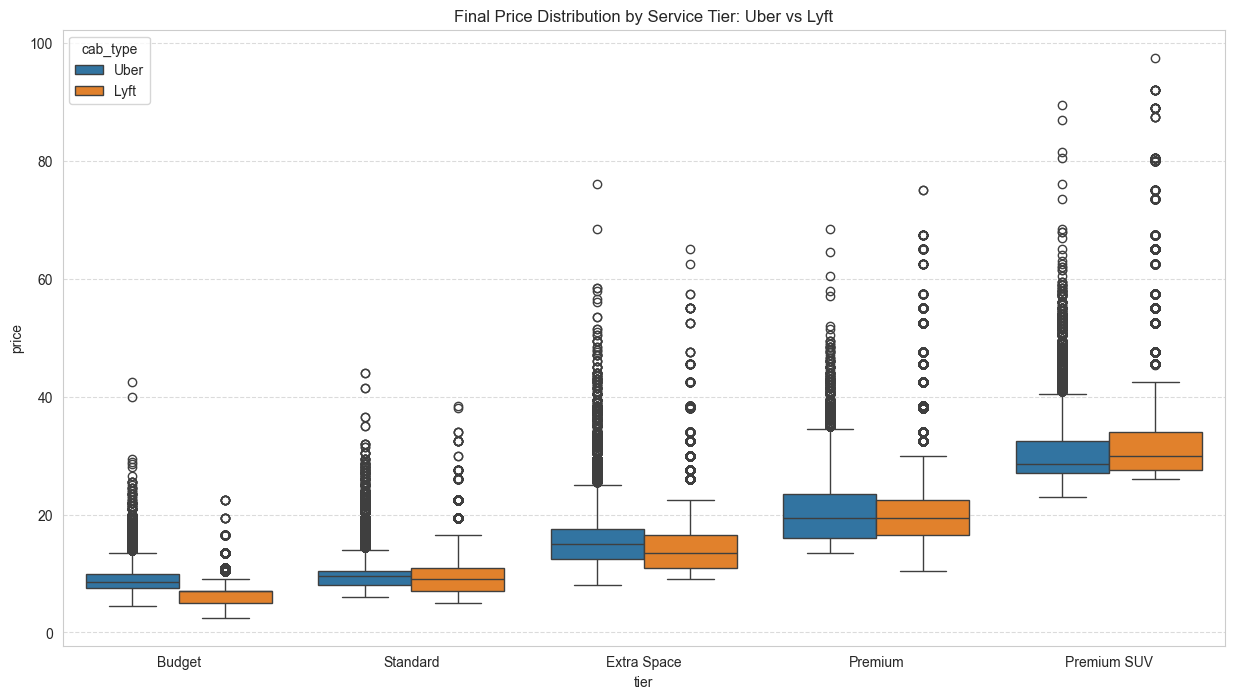

In [66]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_compare, x='tier', y='price', hue='cab_type', order=tier_order)
plt.title('Final Price Distribution by Service Tier: Uber vs Lyft')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

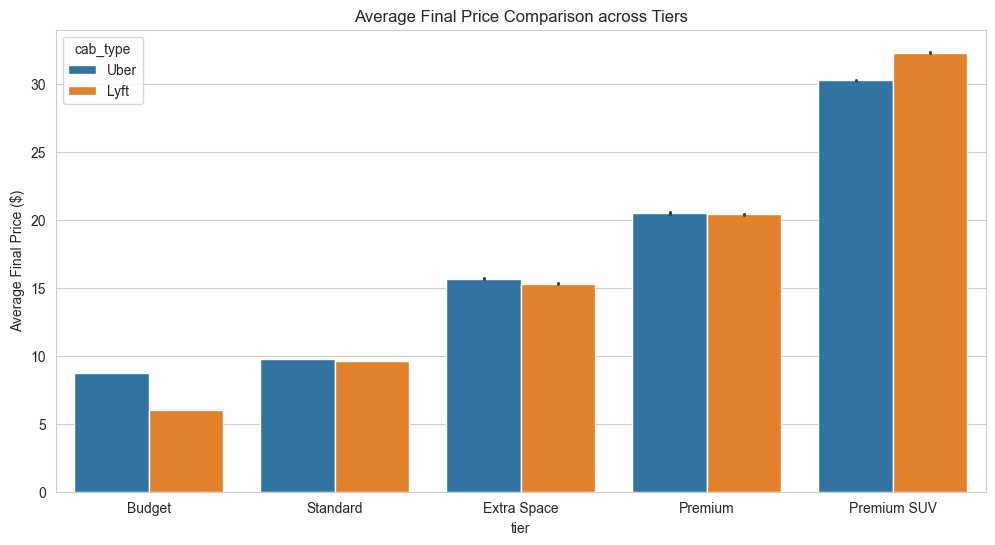

In [68]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_compare, x='tier', y='price', hue='cab_type', order=tier_order, estimator='mean')
plt.title('Average Final Price Comparison across Tiers')
plt.ylabel('Average Final Price ($)')
plt.show()

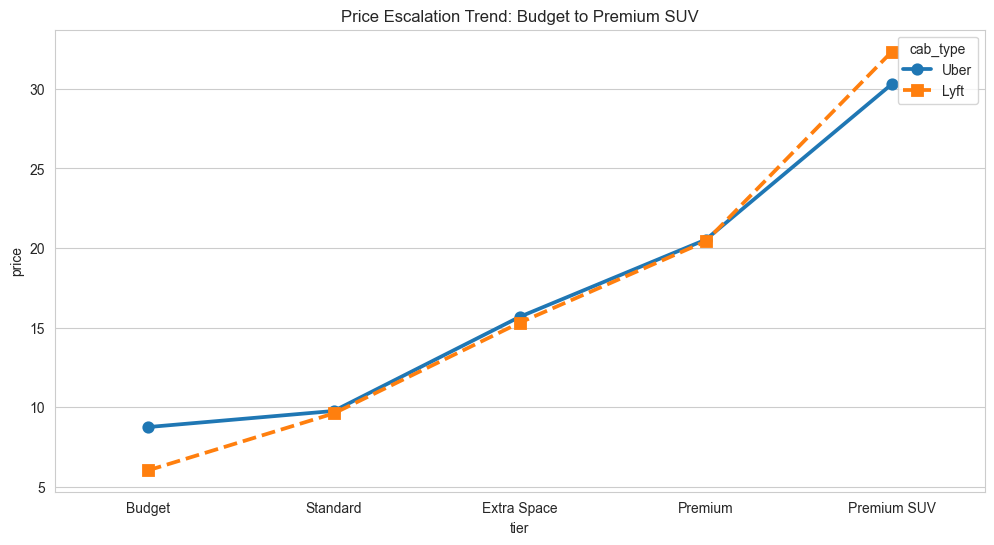

In [69]:
plt.figure(figsize=(12, 6))
sns.pointplot(data=df_compare, x='tier', y='price', hue='cab_type', order=tier_order, markers=["o", "s"], linestyles=["-", "--"])
plt.title('Price Escalation Trend: Budget to Premium SUV')
plt.show()

จากกราฟพบว่า Uber ในระกับบริการ Budget และ Standard มีความใกล้เคียงมาก ในทางกลับกันทาง Lyft ราคา Budget กัย Standard จะมีความชันที่มากกว่านั่นคือความต่างราคาของ 2 ระดับนี้มีมากกว่า นอกจากนี้พบอีกว่า Premium SUV จะมีราคาที่ก้าวกระโดดจากระดับก่อนหน้ามากที่สุดทั้ง Uber และ Lyft

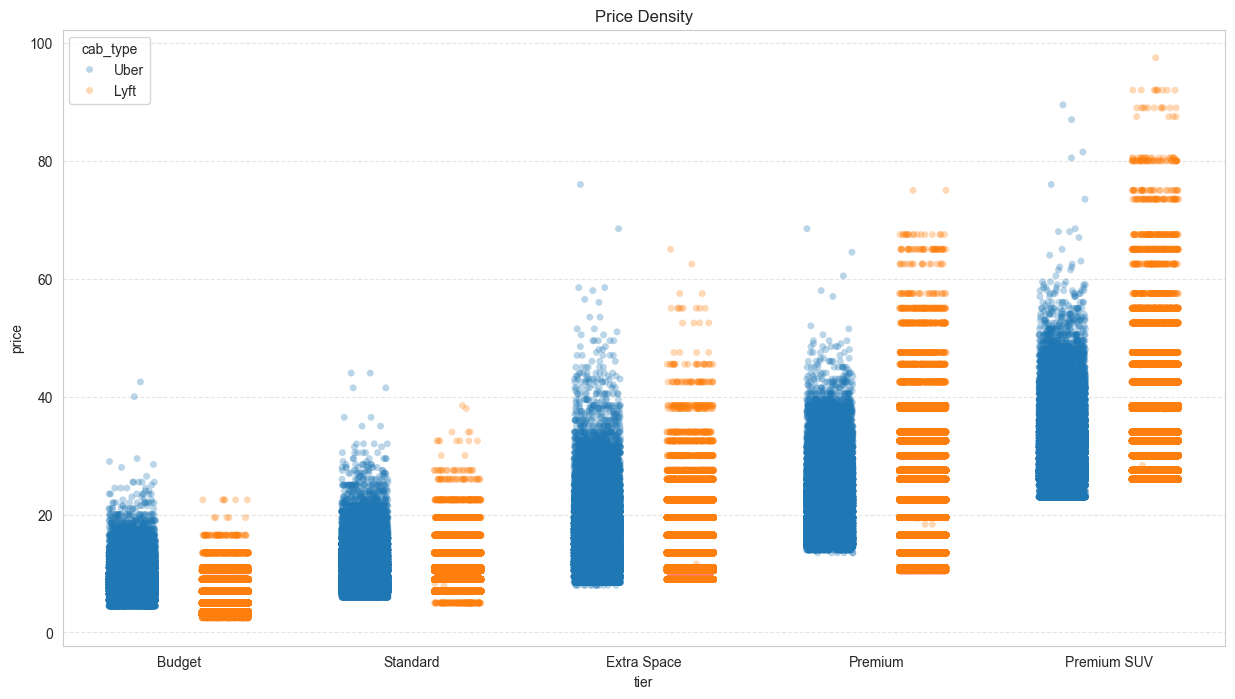

In [144]:
plt.figure(figsize=(15, 8))
sns.stripplot(data=df_compare, x='tier', y='price', hue='cab_type', 
              order=tier_order, dodge=True, alpha=0.3, jitter=0.2)
plt.title('Price Density')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

จากกราฟบ่งบอกความหนาแน่นของราคาในแต่ละระดับบริการ โดยจะพบว่า Uber จะมีราคาที่ต่อเนื่อง แต่ส่วนของ Lyft จะมีลักษณะไม่ต่อเนื่อง เนื่องจากกลยุทธ์ในตลาด Lyft ยังมีการใช้ surge multiplier และมีการปัดเศษทำให้ราคาที่ได้ออกมามักจะเป็นขั้นบันได เช่น .00 หรือ .50 เป็นต้น แต่ในทางกลับกัน ทาง Uber มีกลยุทธ์ที่ละเอียดกว่านั่นคือการใช้โมเดลการคำนวณราคาที่แปรผันตามปัจจัยย่อยๆ เรียกว่า Granular pricing ทำให้ราคาที่ออกมามีความหลากหลายและดูต่อเนื่องมากนั่นเอง

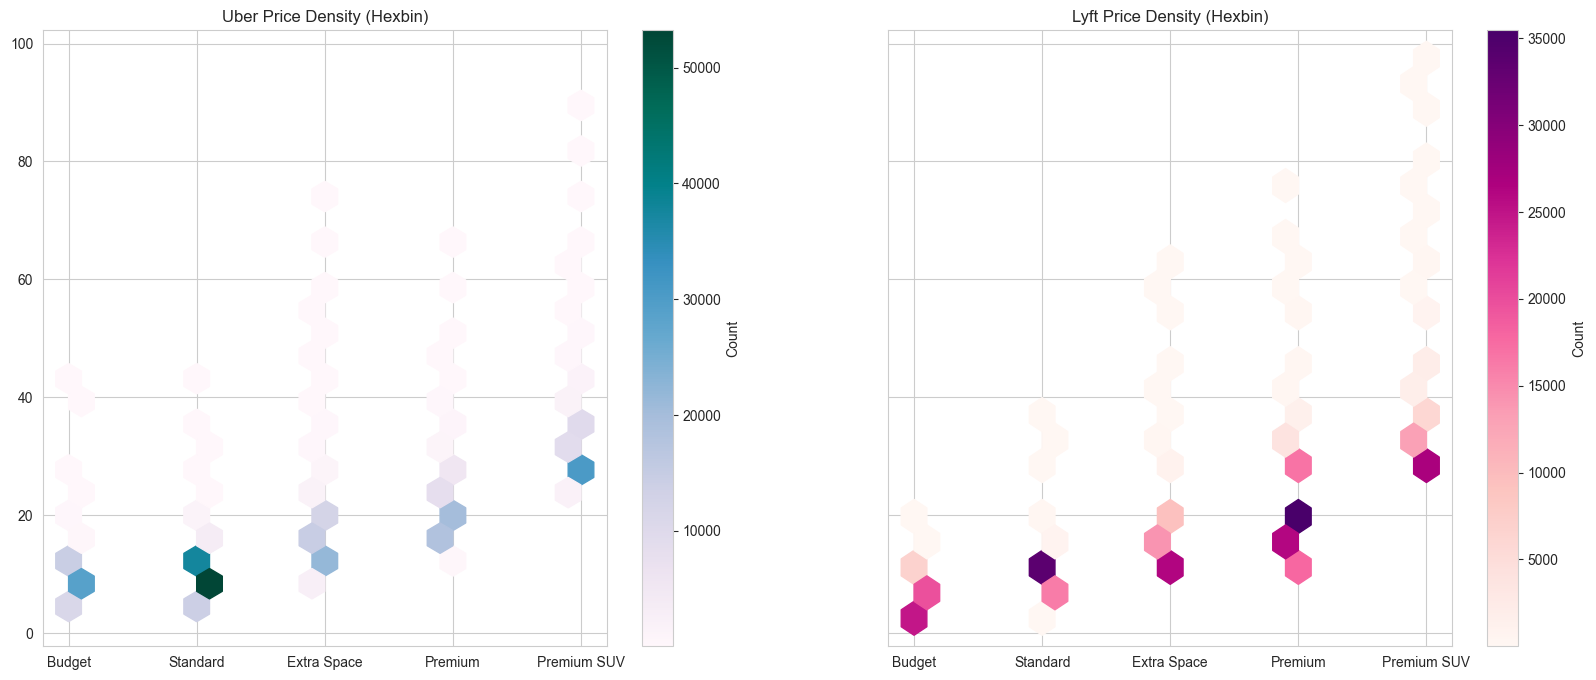

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

df_compare['tier_idx'] = df_compare['tier'].map({t: i for i, t in enumerate(tier_order)})

# Uber Hexbin
hb1 = ax1.hexbin(df_compare[df_compare['cab_type'] == 'Uber']['tier_idx'], 
                 df_compare[df_compare['cab_type'] == 'Uber']['price'], 
                 gridsize=20, cmap='PuBuGn', mincnt=1)
ax1.set_title('Uber Price Density (Hexbin)')
ax1.set_xticks(range(len(tier_order)))
ax1.set_xticklabels(tier_order)

# Lyft Hexbin
hb2 = ax2.hexbin(df_compare[df_compare['cab_type'] == 'Lyft']['tier_idx'], 
                 df_compare[df_compare['cab_type'] == 'Lyft']['price'], 
                 gridsize=20, cmap='RdPu', mincnt=1)
ax2.set_title('Lyft Price Density (Hexbin)')
ax2.set_xticks(range(len(tier_order)))
ax2.set_xticklabels(tier_order)

plt.colorbar(hb1, ax=ax1, label='Count')
plt.colorbar(hb2, ax=ax2, label='Count')
plt.show()

จาก Hexbin ทางตัว Uber พบว่าเมื่อเลือกที่จะใช้บริการ UberX / WAV ที่อยู่ในหมวด Standard มีโอกาสได้ราคาประมาณ 10 มาก โดยที่ราคาที่ในระดับบริการอื่น ๆ มีการกระจายที่ไม่ได้แน่นอนมาก ในทางกลับกันหากเลือกใช้ Lyft ที่เป็นบริการ Premium และ Standard ราคาส่วนใหญ่จะแน่นอนพอสมควร

# Weather

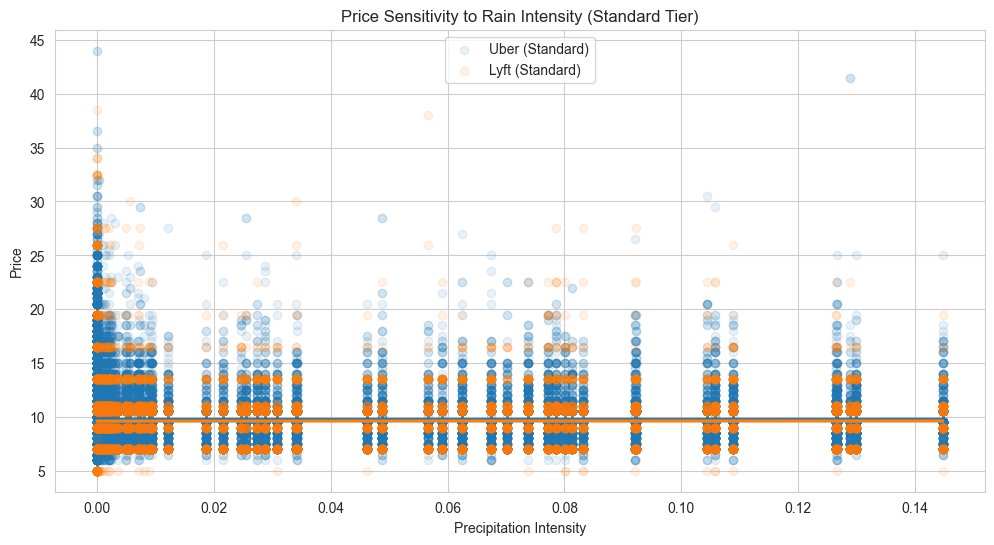

In [146]:
plt.figure(figsize=(12, 6))

# กรองเฉพาะประเภทรถ Standard (UberX vs Lyft) เพื่อความแม่นยำ
standard_df = df_compare[df_compare['tier'] == 'Standard']

sns.regplot(data=standard_df[standard_df['cab_type'] == 'Uber'], 
            x='precipIntensity', y='price', scatter_kws={'alpha':0.1}, label='Uber (Standard)')
sns.regplot(data=standard_df[standard_df['cab_type'] == 'Lyft'], 
            x='precipIntensity', y='price', scatter_kws={'alpha':0.1}, label='Lyft (Standard)')

plt.title('Price Sensitivity to Rain Intensity (Standard Tier)')
plt.xlabel('Precipitation Intensity')
plt.ylabel('Price')
plt.legend()
plt.show()

จากกราฟ Price Sensitivity to Rain Intensity เราพบว่าปริมาณน้ำฝนเมื่อมีเพิ่มขึ้นราคายังกองอยู่บริเวณ 10 ซึ่งเป็นราคาเฉลี่ยของช่วงรถในระดับ Standard อยู่แล้วทำให้บ่งบอกว่าปริมาณน้ำฝนแทบไม่มีผลตาราคาที่นำไปคำนวณ

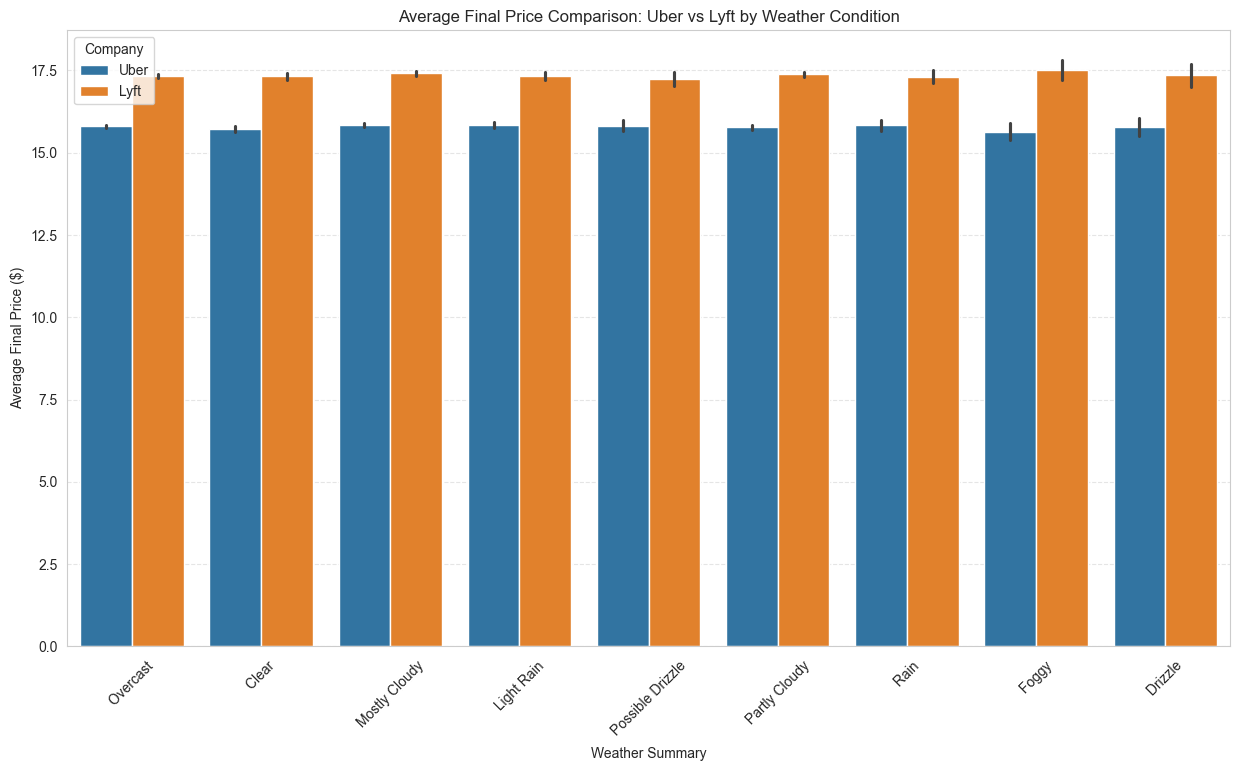

In [76]:
plt.figure(figsize=(15, 8))

sns.barplot(data=df_compare, x='short_summary', y='price', hue='cab_type', estimator='mean')

plt.title('Average Final Price Comparison: Uber vs Lyft by Weather Condition')
plt.xlabel('Weather Summary')
plt.ylabel('Average Final Price ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Company')
plt.show()

กราฟนี้เทียบ price ของแต่ละ weather แบ่งตาม Uber และ Lyft

In [78]:
# ค่าเฉลี่ยราคาแยกตามประเภทรถและสภาพอากาศ
weather_analysis = df_compare.groupby(['cab_type', 'short_summary'])['price'].mean().unstack(level=0)

# ส่วนต่างราคา
weather_analysis['Price_Gap'] = weather_analysis['Lyft'] - weather_analysis['Uber']

# Lyft แพงกว่า Uber กี่ %
weather_analysis['Lyft_Premium_Pct'] = (weather_analysis['Price_Gap'] / weather_analysis['Uber']) * 100

print("Weather Analysis Table (Final Price):")
display(weather_analysis.sort_values(by='Lyft_Premium_Pct', ascending=False))

Weather Analysis Table (Final Price):


cab_type,Lyft,Uber,Price_Gap,Lyft_Premium_Pct
short_summary,,,,
Foggy,17.5062,15.6403,1.8659,11.9302
Partly Cloudy,17.3840,15.7736,1.6104,10.2097
Clear,17.3144,15.7173,1.5971,10.1615
Drizzle,17.3462,15.7749,1.5713,9.9607
Mostly Cloudy,17.4062,15.8426,1.5637,9.8700
Overcast,17.3220,15.7981,1.5239,9.6462
Light Rain,17.3351,15.8417,1.4934,9.4269
Rain,17.3120,15.8289,1.4831,9.3698
Possible Drizzle,17.2398,15.8089,1.4309,9.0512


In [79]:
lyft_df.describe()

,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
count,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000,307408.0000
mean,11.6289,17.7735,11.5871,17.3514,2.1870,1.0313,42.3384,-71.0662,39.5964,35.9047,0.0089,0.1451,0.7407,6.1756,8.4550,8.4739,45.0609,34.1770,41.6432,30.1724,31.6550,1010.1021,220.1930,0.6860,0.2493,313.5015,0.5795,0.0374,33.4668,45.2793,29.7486,42.0233
std,6.9557,9.9914,0.4924,10.0192,1.0866,0.1356,0.0476,0.0203,6.7304,7.9185,0.0268,0.3281,0.1385,3.1450,5.2821,2.5999,5.9987,6.3657,7.6660,8.0345,9.1326,13.4944,98.9664,0.3586,0.4750,27.9512,0.2447,0.0552,6.4620,5.6496,7.1013,6.9413
min,0.0000,1.0000,11.0000,2.5000,0.3900,1.0000,42.2148,-71.1054,18.9100,12.1300,0.0000,0.0000,0.3800,0.4500,0.8000,0.7170,32.6800,17.8500,22.6200,11.8100,4.3900,988.0900,2.0000,0.0000,0.0000,269.4000,0.0900,0.0000,15.6300,33.5100,11.8100,28.9500
25%,6.0000,13.0000,11.0000,9.0000,1.2700,1.0000,42.3503,-71.0810,36.4500,31.9100,0.0000,0.0000,0.6400,3.4100,4.0600,8.4320,42.5700,30.1700,36.5700,27.7000,27.4900,999.8200,124.0000,0.3700,0.0000,290.9000,0.3000,0.0000,30.1700,42.5700,27.7600,36.5700
50%,12.0000,17.0000,12.0000,16.5000,2.1400,1.0000,42.3519,-71.0631,40.4900,35.9000,0.0000,0.0000,0.7100,5.9100,7.5500,9.8800,44.6800,34.1800,40.9500,30.0300,30.6900,1009.2500,258.0000,0.8200,0.0000,307.4000,0.6800,0.0004,34.2400,44.6800,30.1300,40.9500
75%,18.0000,28.0000,12.0000,22.5000,2.9700,1.0000,42.3647,-71.0542,43.5800,40.0800,0.0000,0.0000,0.8800,8.4100,11.7400,9.9960,46.9100,38.7300,44.1200,35.3200,38.1200,1021.8600,303.0000,1.0000,0.0000,332.2000,0.7900,0.0916,38.8800,46.9100,35.7100,44.1200
max,23.0000,30.0000,12.0000,97.5000,6.3300,3.0000,42.3661,-71.0330,57.2200,57.2200,0.1447,1.0000,0.9600,15.0000,27.2500,10.0000,57.8700,46.6000,57.2000,47.2500,50.6700,1035.5500,356.0000,1.0000,2.0000,378.9000,0.9300,0.1459,43.1000,57.8700,40.0500,57.2000


In [80]:
uber_df.describe()

,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
count,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000,330568.0000
mean,11.6089,17.8202,11.5860,15.7953,2.1914,1.0000,42.3380,-71.0661,39.5694,35.8540,0.0090,0.1468,0.7414,6.1972,8.4851,8.4648,45.0198,34.1228,41.5839,30.1059,31.6498,1010.0840,220.0380,0.6865,0.2488,313.5288,0.5787,0.0374,33.4463,45.2419,29.7108,41.9704
std,6.9424,9.9733,0.4925,8.5603,1.1790,0.0000,0.0481,0.0203,6.7209,7.9161,0.0269,0.3294,0.1387,3.1505,5.2947,2.6036,5.9935,6.3965,7.6643,8.0763,9.1496,13.4581,99.1994,0.3586,0.4736,27.9516,0.2446,0.0552,6.4704,5.6396,7.1178,6.9301
min,0.0000,1.0000,11.0000,4.5000,0.0200,1.0000,42.2148,-71.1054,18.9100,12.1300,0.0000,0.0000,0.3800,0.4500,0.8000,0.7170,32.6800,17.8500,22.6200,11.8100,4.3900,988.0900,2.0000,0.0000,0.0000,269.4000,0.0900,0.0000,15.6300,33.5100,11.8100,28.9500
25%,6.0000,13.0000,11.0000,9.0000,1.3000,1.0000,42.3503,-71.0810,36.4500,31.9100,0.0000,0.0000,0.6400,3.4100,4.0600,8.4320,42.5700,28.9000,36.5700,27.6400,27.4600,999.8400,124.0000,0.3700,0.0000,290.9000,0.3000,0.0000,30.1700,42.5700,27.7600,36.5700
50%,12.0000,17.0000,12.0000,12.5000,2.1700,1.0000,42.3519,-71.0631,40.4900,35.9000,0.0000,0.0000,0.7100,5.9100,7.5500,9.8780,44.6600,34.1400,40.9500,30.0300,30.6900,1009.2500,258.0000,0.8200,0.0000,307.4000,0.6800,0.0004,34.2400,44.6600,30.1300,40.9500
75%,18.0000,28.0000,12.0000,21.5000,2.8400,1.0000,42.3647,-71.0542,43.5800,40.0100,0.0000,0.0000,0.8800,8.4100,11.7400,9.9960,46.9100,38.7300,44.0900,35.3200,38.1200,1021.8600,303.0000,1.0000,0.0000,331.8000,0.7900,0.0916,38.8800,46.9100,35.3300,44.0900
max,23.0000,30.0000,12.0000,89.5000,7.8600,1.0000,42.3661,-71.0330,57.2200,57.2200,0.1447,1.0000,0.9600,15.0000,27.2500,10.0000,57.8700,46.6000,57.2000,47.2500,50.6700,1035.5500,356.0000,1.0000,2.0000,378.9000,0.9300,0.1459,43.1000,57.8700,40.0500,57.2000


C:\Users\user\AppData\Local\Temp\ipykernel_30044\3355175338.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lyft_df, x='short_summary', y='price', order=order, palette='magma')


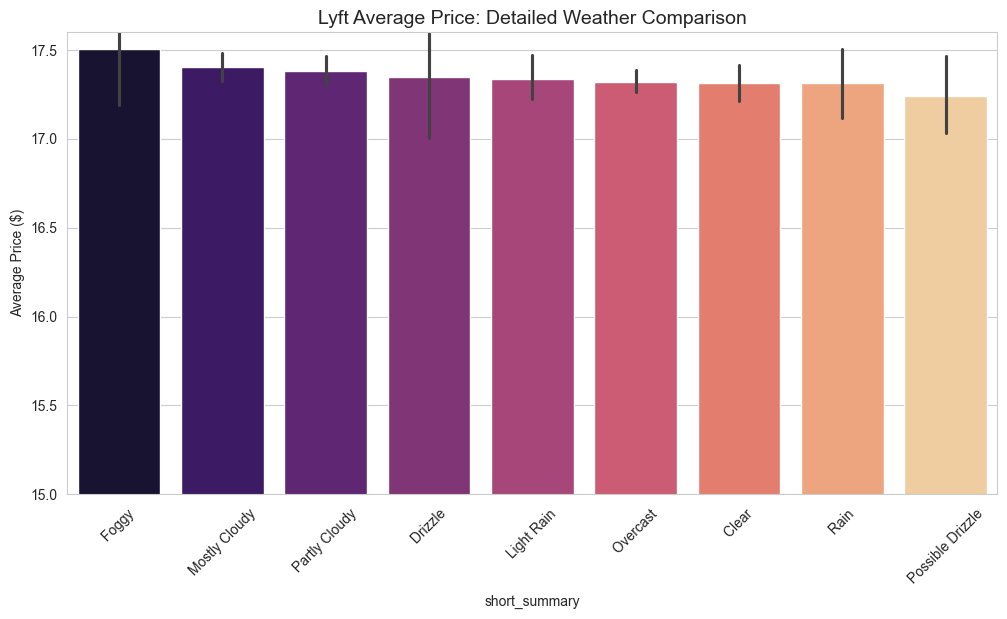

In [98]:
plt.figure(figsize=(12, 6))

order = lyft_df.groupby('short_summary')['price'].mean().sort_values(ascending=False).index

sns.barplot(data=lyft_df, x='short_summary', y='price', order=order, palette='magma')
plt.ylim(15, 17.6) 

plt.title('Lyft Average Price: Detailed Weather Comparison', fontsize=14)
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_30044\3286943421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=uber_df, x='short_summary', y='price', order=order, palette='magma')


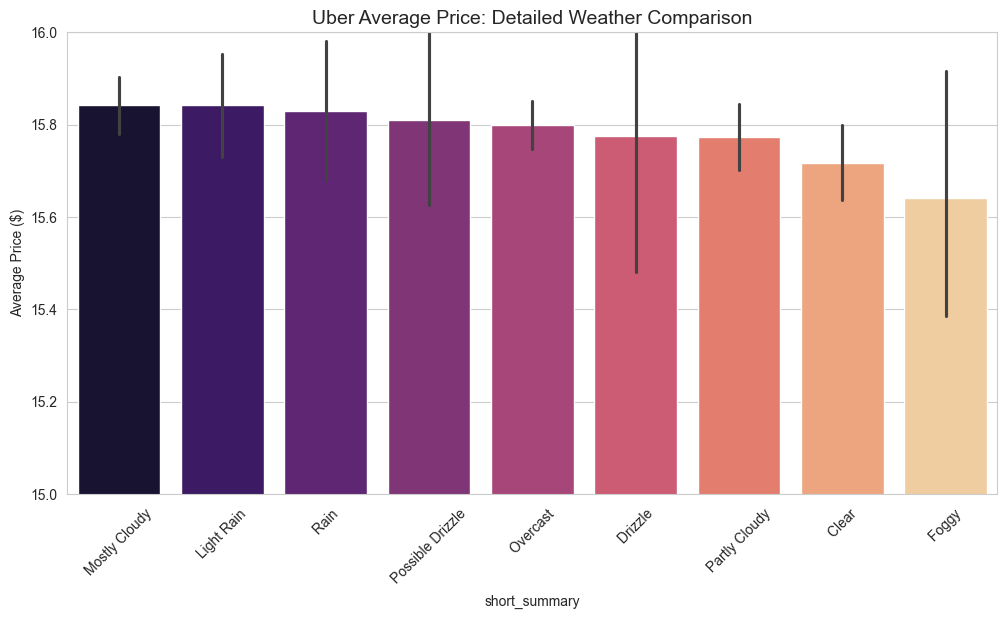

In [150]:
plt.figure(figsize=(12, 6))

order = uber_df.groupby('short_summary')['price'].mean().sort_values(ascending=False).index

sns.barplot(data=uber_df, x='short_summary', y='price', order=order, palette='magma')
plt.ylim(15, 16)

plt.title('Uber Average Price: Detailed Weather Comparison', fontsize=14)
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_30044\3068240798.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=uber_ratio.index, y=uber_ratio.values, ax=ax1, palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_30044\3068240798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lyft_ratio.index, y=lyft_ratio.values, ax=ax2, palette='magma')


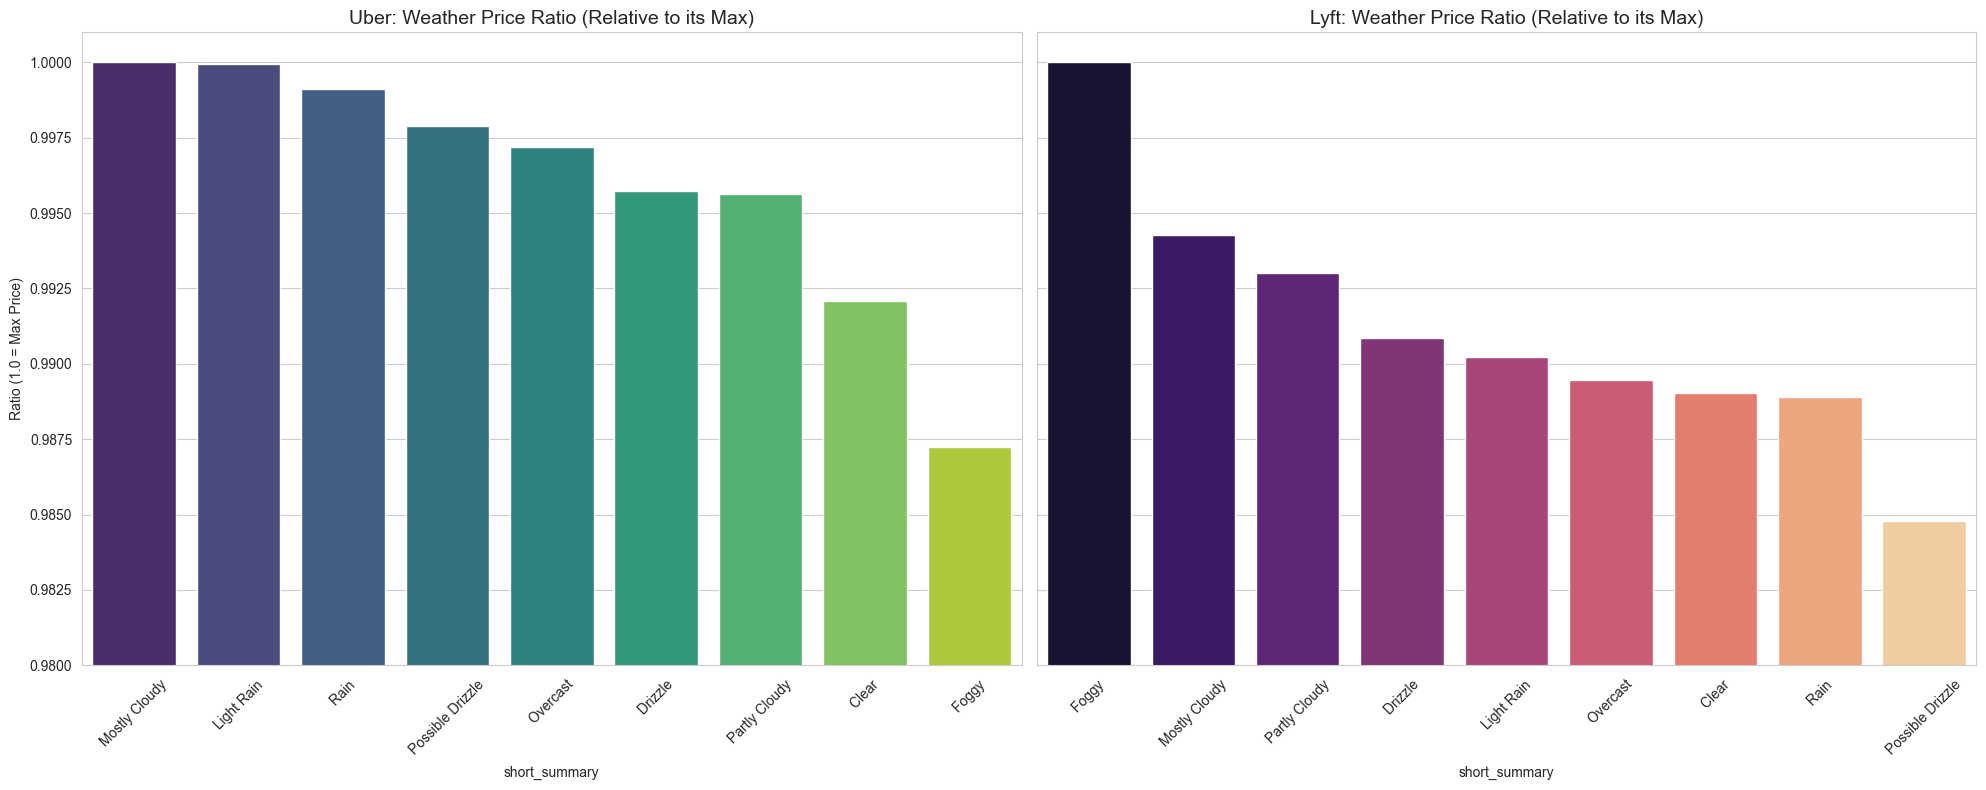

In [112]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# ฟังก์ชันคำนวณ Ratio (ราคา / ราคาเฉลี่ยสูงสุดของเจ้านั้นๆ)
def get_ratio(df):
    max_val = df.groupby('short_summary')['price'].mean().max()
    return df.groupby('short_summary')['price'].mean() / max_val

uber_ratio = get_ratio(uber_df).sort_values(ascending=False)
lyft_ratio = get_ratio(lyft_df).sort_values(ascending=False)

# Uber
sns.barplot(x=uber_ratio.index, y=uber_ratio.values, ax=ax1, palette='viridis')
ax1.set_title('Uber: Weather Price Ratio (Relative to its Max)', fontsize=14)
ax1.set_ylabel('Ratio (1.0 = Max Price)')
ax1.tick_params(axis='x', rotation=45)

# Lyft
sns.barplot(x=lyft_ratio.index, y=lyft_ratio.values, ax=ax2, palette='magma')
ax2.set_title('Lyft: Weather Price Ratio (Relative to its Max)', fontsize=14)
ax2.tick_params(axis='x', rotation=45)

plt.ylim(0.98, 1.001) 
plt.tight_layout()
plt.show()

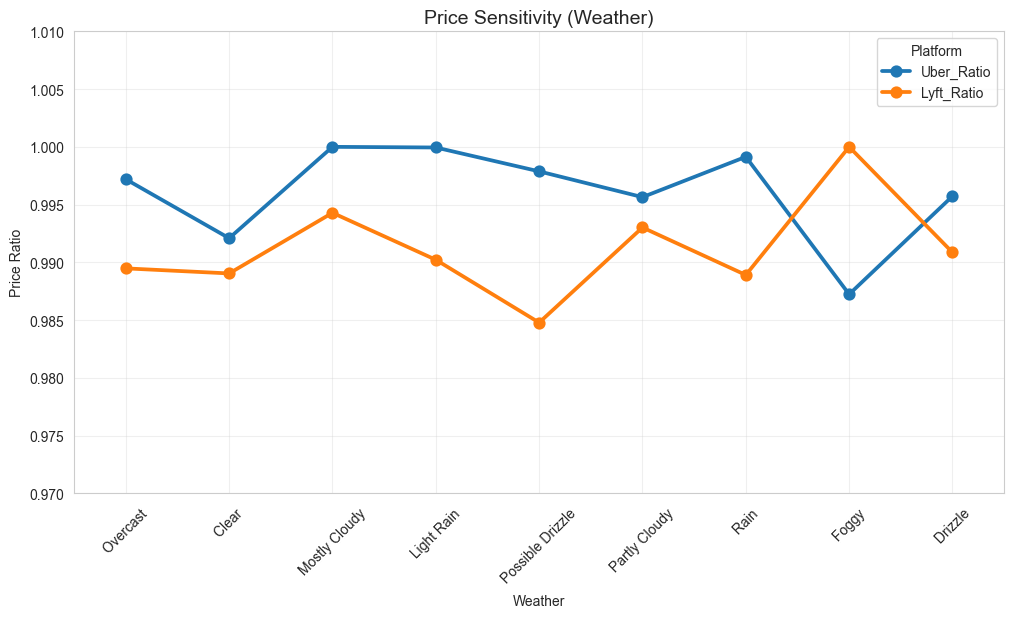

In [133]:
ratio_df = pd.DataFrame({
    'Weather': uber_ratio.index,
    'Uber_Ratio': uber_ratio.values,
    'Lyft_Ratio': lyft_ratio.reindex(uber_ratio.index).values # เรียงตาม Uber เพื่อให้เทียบง่าย
}).melt(id_vars='Weather', var_name='Platform', value_name='Ratio')

weather_order = [' Overcast ', ' Clear ', ' Mostly Cloudy ', ' Light Rain ', ' Possible Drizzle ', ' Partly Cloudy ', ' Rain ', ' Foggy ', ' Drizzle ']

plt.figure(figsize=(12, 6))
sns.pointplot(data=ratio_df, x='Weather', y='Ratio', hue='Platform', order=weather_order)

plt.ylim(0.97, 1.01)
plt.title('Price Sensitivity (Weather)', fontsize=14)
plt.ylabel('Price Ratio')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

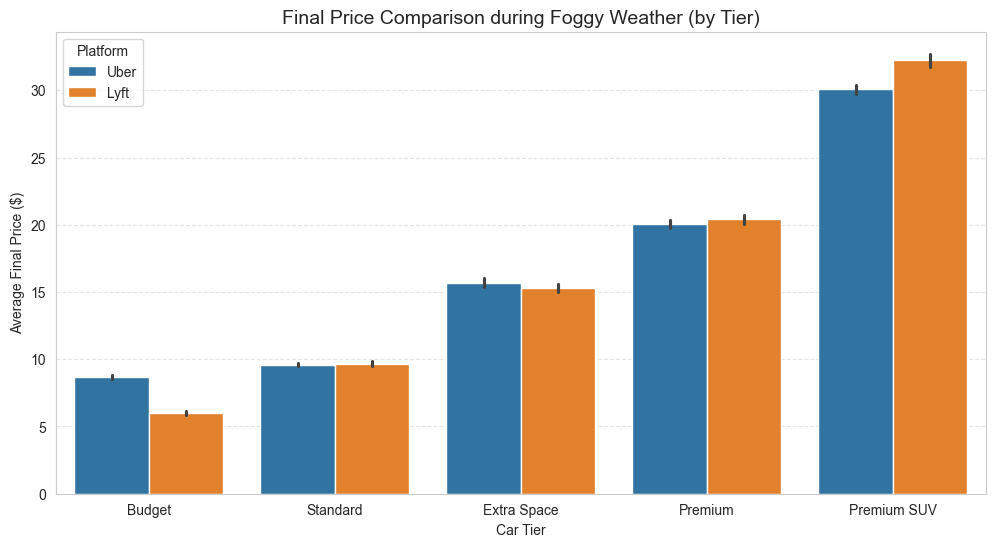

In [129]:
foggy_df = df_compare[df_compare['short_summary'] == ' Foggy ']

plt.figure(figsize=(12, 6))

sns.barplot(data=foggy_df, x='tier', y='price', hue='cab_type', order=tier_order, estimator='mean')

plt.title('Final Price Comparison during Foggy Weather (by Tier)', fontsize=14)
plt.ylabel('Average Final Price ($)')
plt.xlabel('Car Tier')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Platform')
plt.show()

In [127]:
print(df_compare['short_summary'].unique())

[' Overcast ' ' Clear ' ' Mostly Cloudy ' ' Light Rain '
 ' Possible Drizzle ' ' Partly Cloudy ' ' Rain ' ' Foggy ' ' Drizzle ']


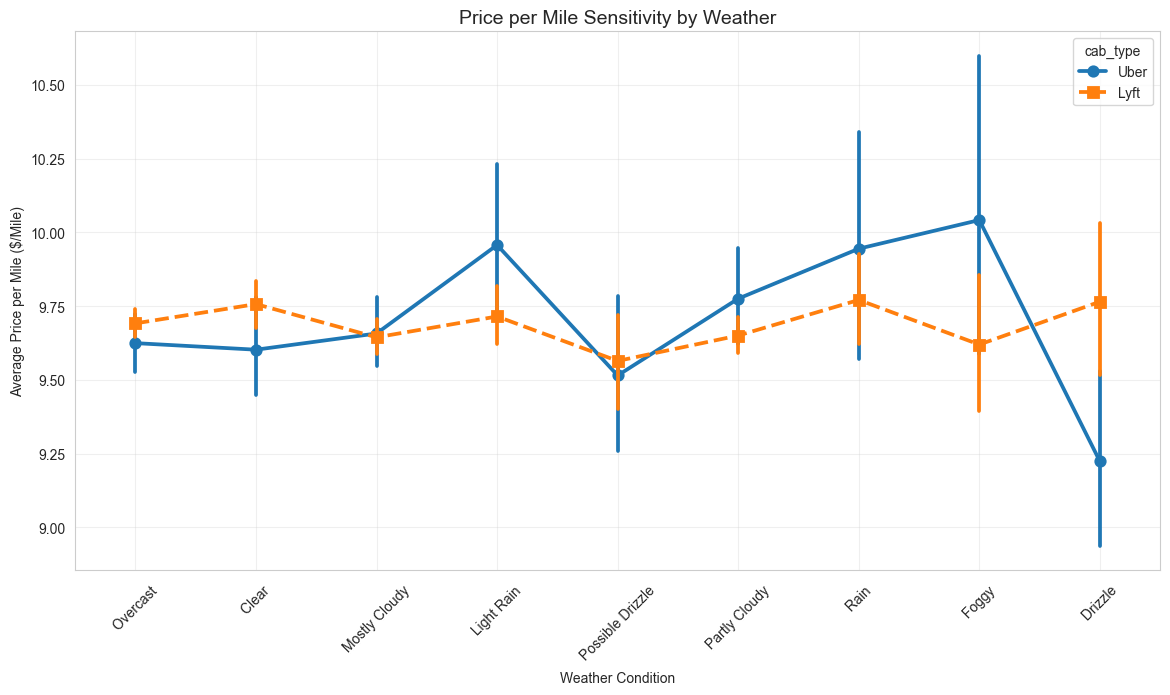

In [137]:
df_compare['price_per_mile'] = df_compare['price'] / df_compare['distance']

plt.figure(figsize=(14, 7))

# ใช้ Point Plot เพื่อดู "ความไว" ของราคาต่อไมล์
sns.pointplot(data=df_compare, x='short_summary', y='price_per_mile', hue='cab_type', 
              order=weather_order, markers=["o", "s"], linestyles=["-", "--"])

plt.title('Price per Mile Sensitivity by Weather', fontsize=14)
plt.ylabel('Average Price per Mile ($/Mile)')
plt.xlabel('Weather Condition')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

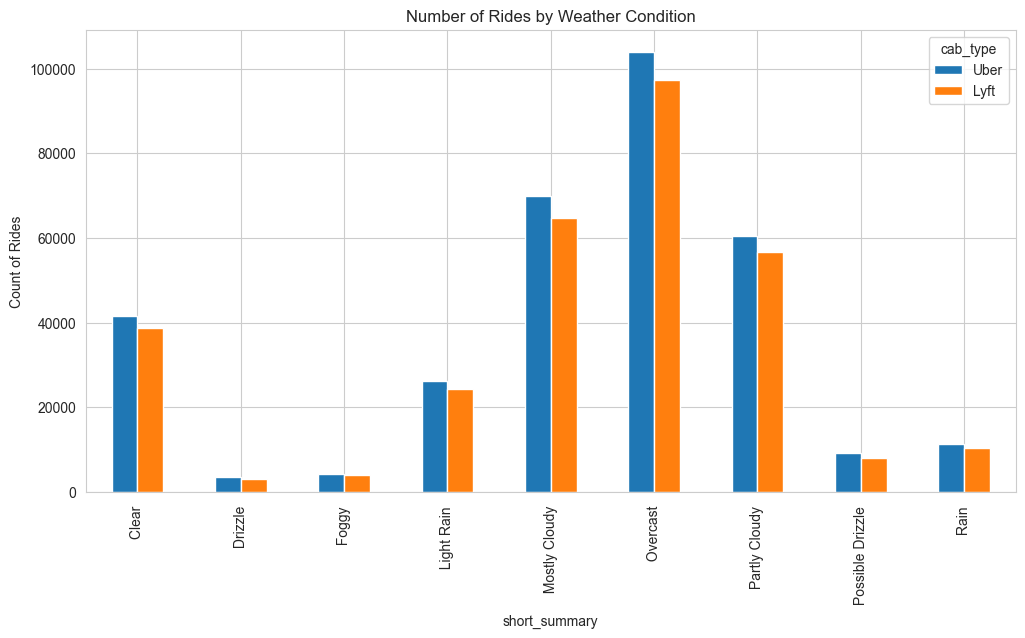

cab_type             Uber   Lyft
short_summary                   
Clear               41603  38653
Drizzle              3614   3111
Foggy                4290   4002
Light Rain          26160  24328
Mostly Cloudy       69883  64720
Overcast           104013  97416
Partly Cloudy       60563  56663
Possible Drizzle     9104   8072
Rain                11338  10443


In [143]:
weather_counts = df_compare.groupby(['short_summary', 'cab_type']).size().unstack()
weather_counts = weather_counts[['Uber', 'Lyft']]

weather_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Number of Rides by Weather Condition')
plt.ylabel('Count of Rides')
plt.show()

print(weather_counts)

สรุปได้ว่า Price Sensitivity ของ Uber และ Lyft พบสิ่งที่น่าสนใจคือ Lyft เมื่ออยู่ในสภาพอากาศ Foggy ราคาจะมีการตื่นตัวมากที่สุด โดยผิดหูผิดตากับ Uber ที่มี Sensivity ที่ต่ำที่สุด แต่เมื่อลองเปรียบเทียบ Price per Mile พบว่า Uber เก็บเงินจริงตามราคาต่อระยะทางที่เยอะกว่าซึ่งเยอะที่สุดถ้าเทียบภายในสภาอากาศกันเอง แต่ทางกลับกัน Lyft จะมีการเก็บเงินต่อระยะทางต่ำเกือบจะที่สุดจากผลกระทบของสภาพอากาศของตัว Lyft เอง